Determine if small fragments are driving replication estimations for 10kb windows

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [28]:
from src.mnase_10kb_loader import MNase10kbLoader

loader = MNase10kbLoader()
loader.load_mnase_data(replicate=1, chromosome=4)
loader.compute_sliding_window_counts_all_times()
all_read_counts_df = loader.normalized_total_occupancy_df


In [29]:
from src.chromatin_metrics import fragment_lengths_definitions
small_span, med_span, nuc_span = fragment_lengths_definitions()

# Select only nucleosome read counts
loader.load_mnase_data(replicate=1, chromosome=4, fragment_lengths_span=nuc_span)
loader.compute_sliding_window_counts_all_times()
nucleosomal_fragments_read_counts_df = loader.normalized_total_occupancy_df

# Select only nucleosome read counts
loader.load_mnase_data(replicate=1, chromosome=4, fragment_lengths_span=small_span)
loader.compute_sliding_window_counts_all_times()
small_fragments_read_counts_df = loader.normalized_total_occupancy_df


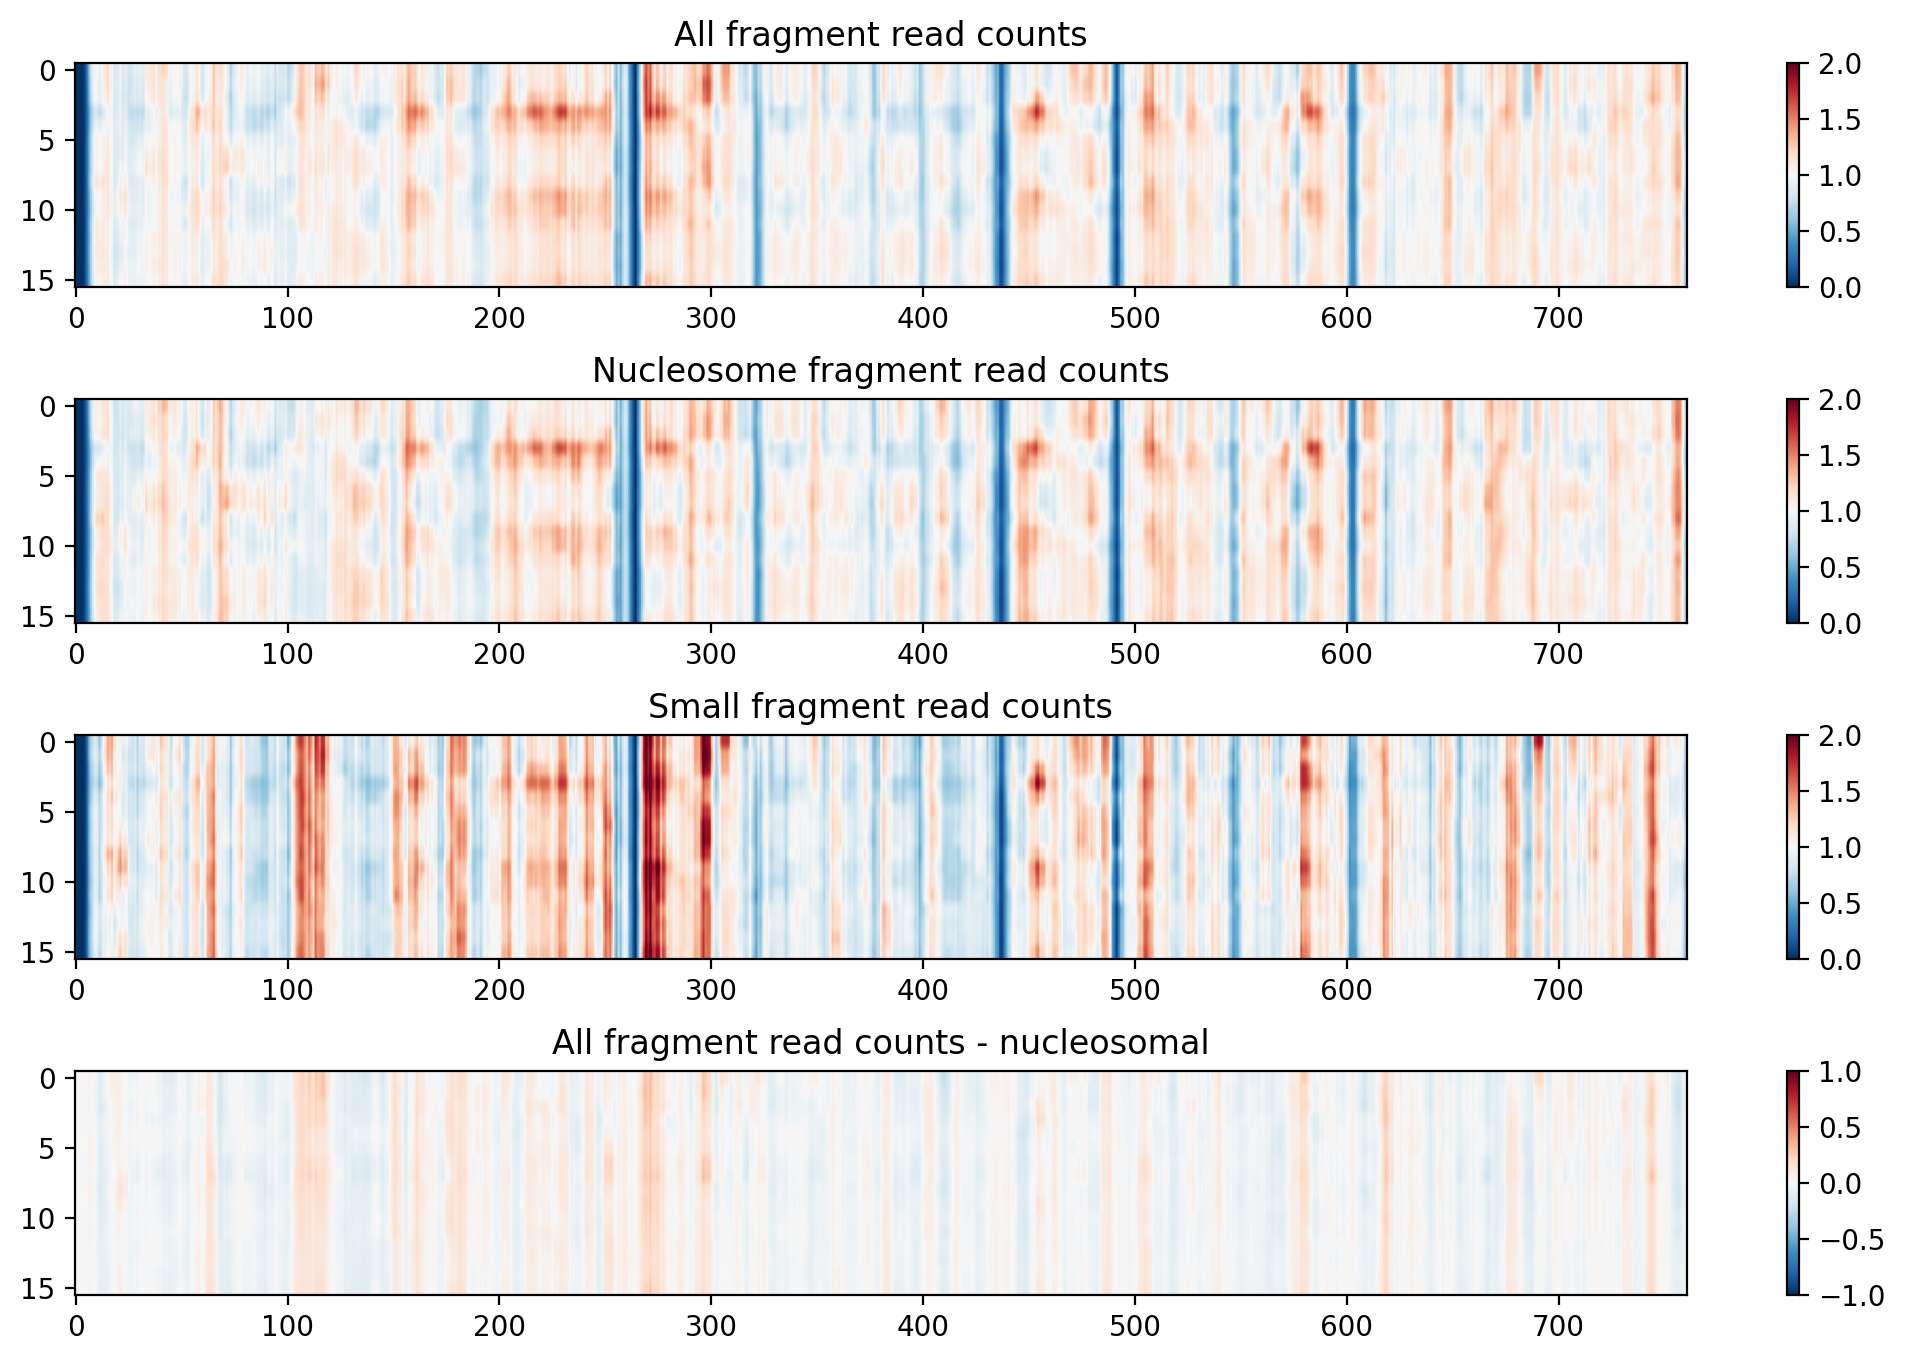

In [30]:
plt.figure(figsize=(13, 8))
plt.subplot(4, 1, 1)
plt.imshow(all_read_counts_df.T, aspect='auto',
          cmap='RdBu_r', vmin=0, vmax=2)
plt.title("All fragment read counts")
plt.colorbar()

plt.subplot(4, 1, 2)
plt.imshow(nucleosomal_fragments_read_counts_df.T, aspect='auto',
          cmap='RdBu_r', vmin=0, vmax=2)
plt.title("Nucleosome fragment read counts")
plt.colorbar()

plt.subplot(4, 1, 3)
plt.imshow(small_fragments_read_counts_df.T, aspect='auto',
          cmap='RdBu_r', vmin=0, vmax=2)
plt.title("Small fragment read counts")
plt.colorbar()

plt.subplot(4, 1, 4)
plt.imshow((all_read_counts_df-nucleosomal_fragments_read_counts_df).T, 
           aspect='auto', vmin=-1, vmax=1, cmap='RdBu_r')
plt.title("All fragment read counts - nucleosomal")
plt.colorbar()
plt.subplots_adjust(hspace=0.5)

In [34]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

# Let's deconvolve the replication profile using nucleosome fragments
# and compare the results to the previous run. We can initialize the parameters to save time.
config, _ = load_default_chrom_configs()

config.shift_parameters_for_alpha()
real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

In [107]:
# Update parameters to initialize using previous 1000 epoch run
real_deconv1.update_parameters({'mu0': 4.926855997420141,
 'delta': 15.130663943754426,
 'sigma0': 6.288228436658738,
 'sigmav': 0.028913623544450304,
 'lambda': 60.0,
 'gamma1': 0.5,
 'gamma2': 0.84,
 'halted': 7.473645129759716e-05,
 'alpha': 22})

real_deconv1.iterative_deconvolution_updates(20)

Iteration 0
0/702 - 00:00:00.007
100/702 - 00:00:00.071
200/702 - 00:00:00.131
300/702 - 00:00:00.188
400/702 - 00:00:00.248
500/702 - 00:00:00.306
600/702 - 00:00:00.362
700/702 - 00:00:00.421
Iteration completed 00:00:00.574, rn=0.030693202238040982
Iteration 1
0/702 - 00:00:00.576
100/702 - 00:00:00.640
200/702 - 00:00:00.699
300/702 - 00:00:00.763
400/702 - 00:00:00.823
500/702 - 00:00:00.883
600/702 - 00:00:00.946
700/702 - 00:00:01.005
Iteration completed 00:00:01.206, rn=0.003680457127432459
Iteration 2
0/702 - 00:00:01.208
100/702 - 00:00:01.269
200/702 - 00:00:01.337
300/702 - 00:00:01.399
400/702 - 00:00:01.460
500/702 - 00:00:01.517
600/702 - 00:00:01.577
700/702 - 00:00:01.646
Iteration completed 00:00:01.760, rn=0.003015444634223252
Iteration 3
0/702 - 00:00:01.762
100/702 - 00:00:01.820
200/702 - 00:00:01.885
300/702 - 00:00:01.950
400/702 - 00:00:02.039
500/702 - 00:00:02.107
600/702 - 00:00:02.164
700/702 - 00:00:02.221
Iteration completed 00:00:02.408, rn=0.00286728489

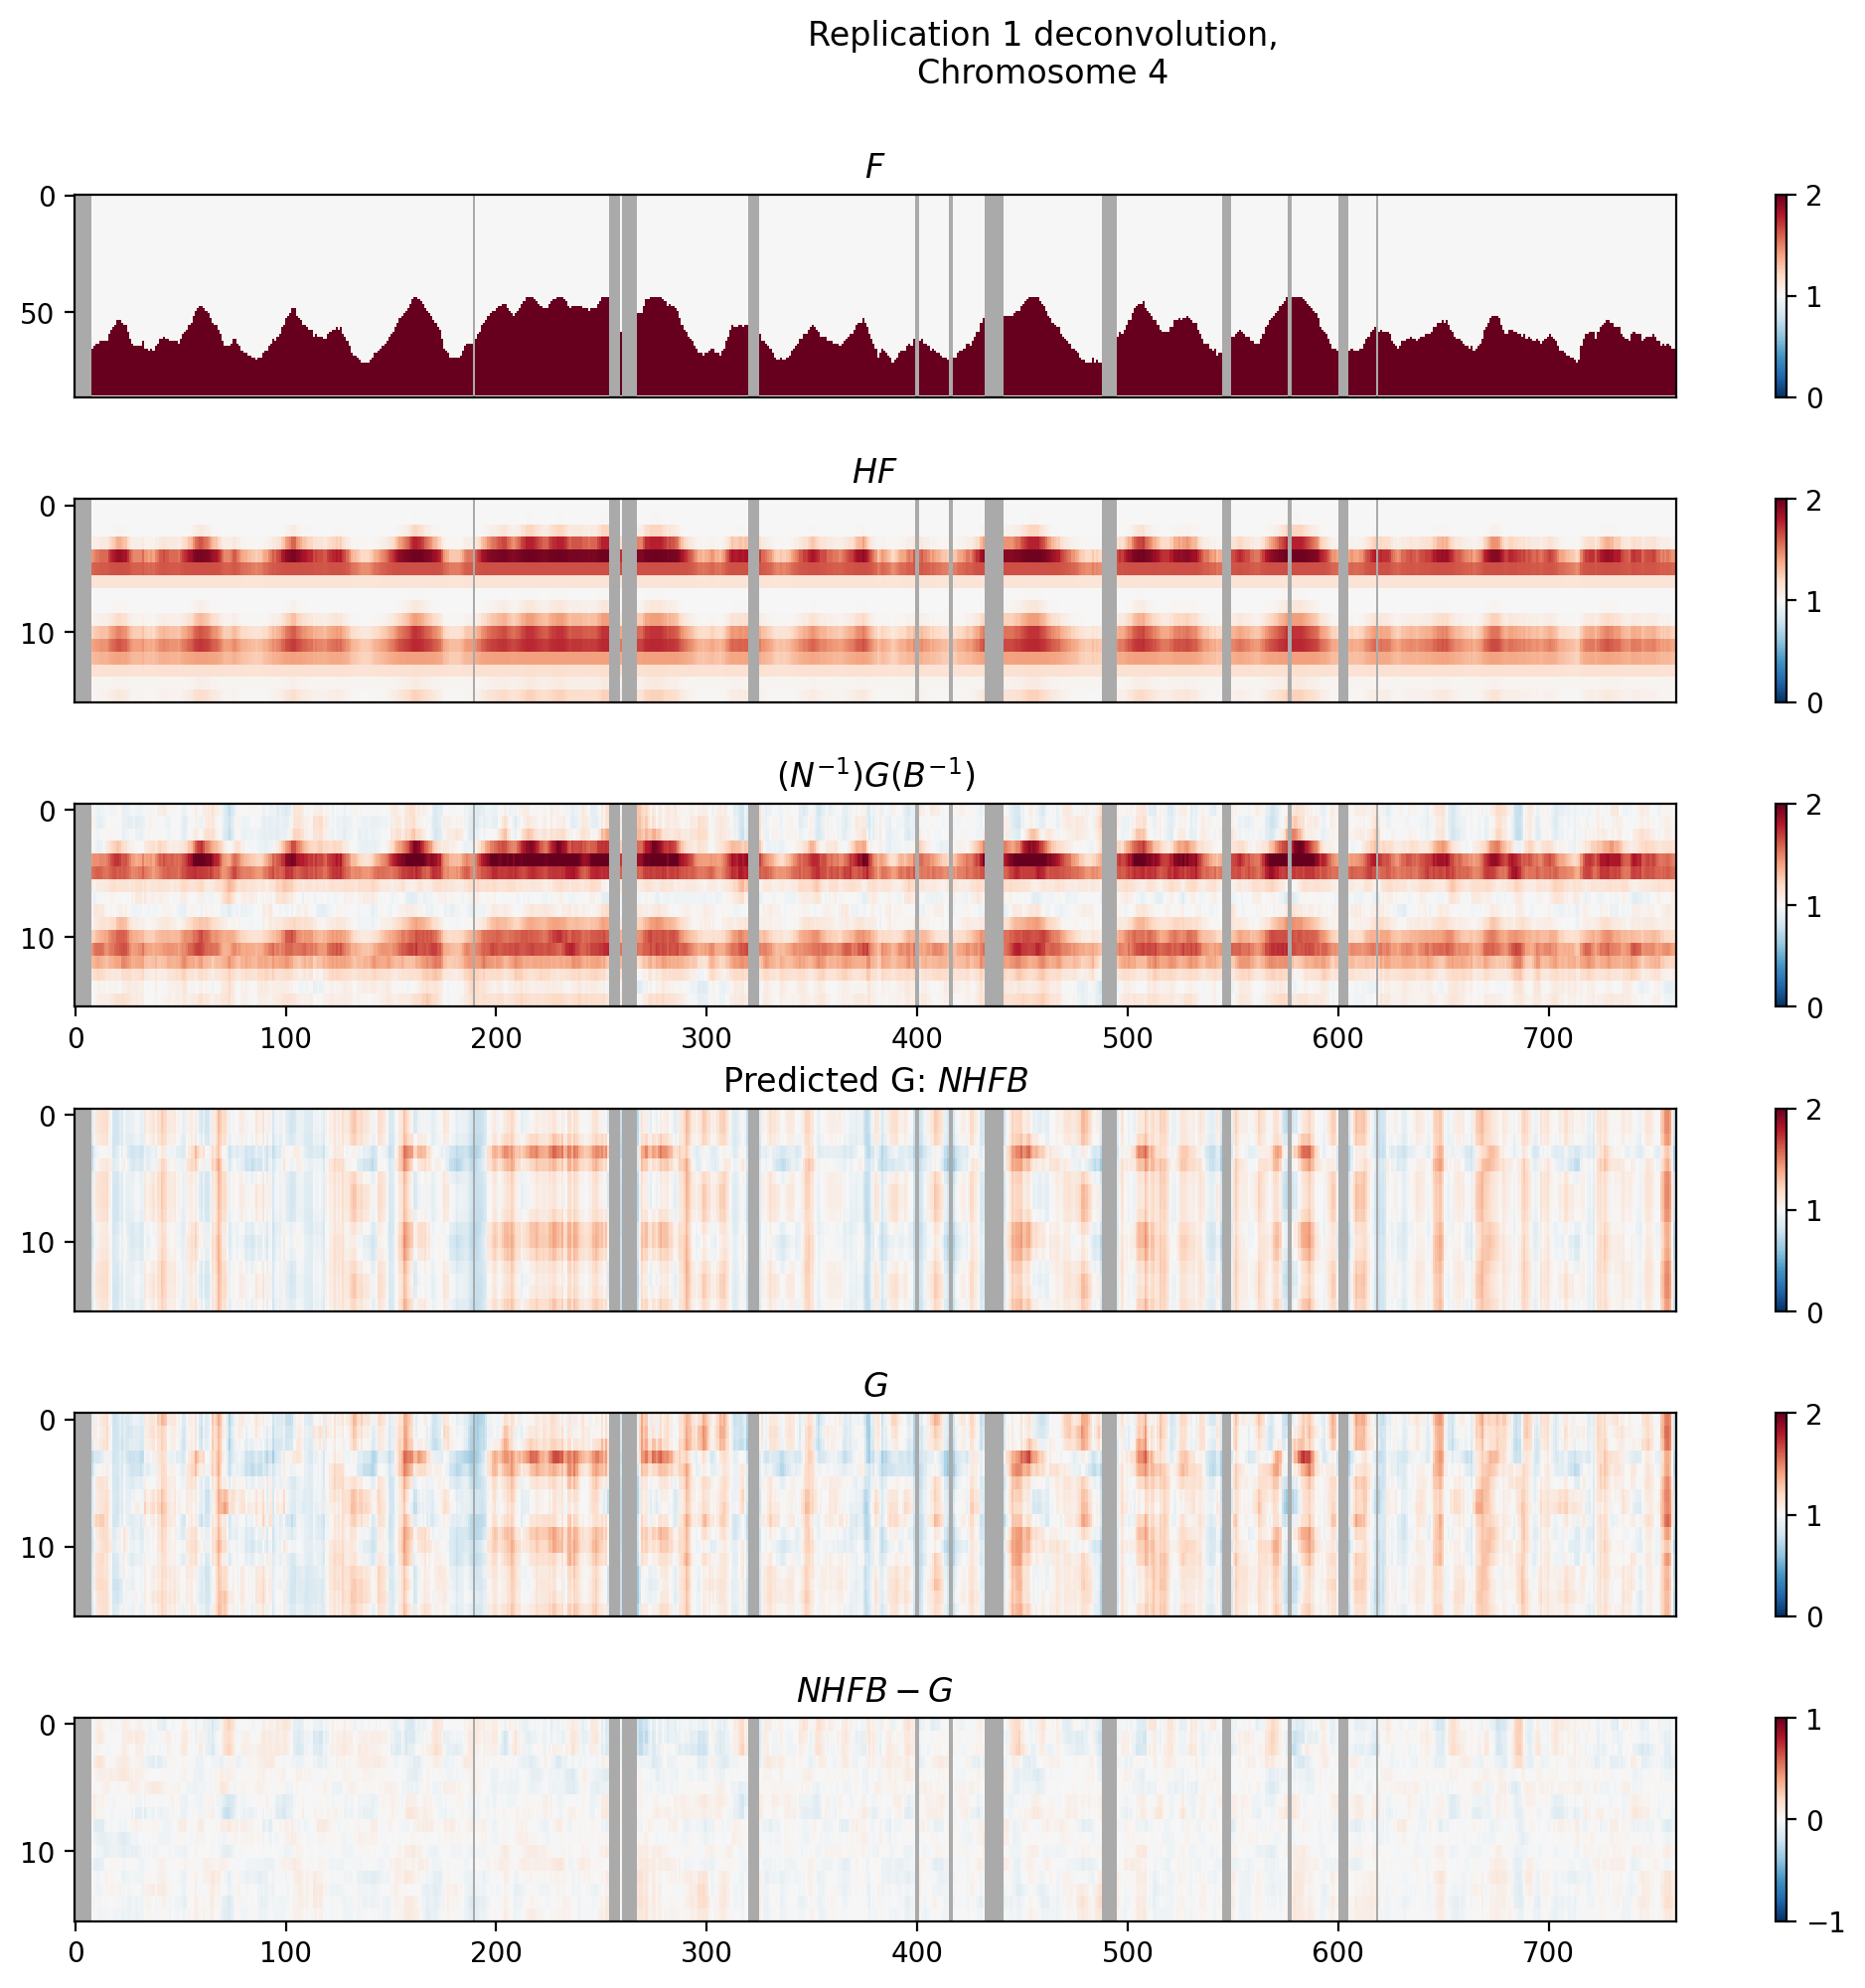

In [108]:
real_deconv1.plot_heatmaps()

In [109]:
from src.optimize_H import run_epochs, create_bounds_params_from_config

params_df = create_bounds_params_from_config(config)

In [110]:
update_params_df, Hs, Fs, Ns, Bs = run_epochs(real_deconv1, params_df, num_epochs=10)

Epoch:  0
Optimization [1]: Current loss: 0.0028236890315804057
Optimization [101]: Current loss: 0.002822458094905946
Optimization terminated successfully.
         Current function value: 0.002822
         Iterations: 68
         Function evaluations: 124
Iteration 0
0/702 - 00:00:26.858
100/702 - 00:00:26.913
200/702 - 00:00:26.969
300/702 - 00:00:27.026
400/702 - 00:00:27.079
500/702 - 00:00:27.132
600/702 - 00:00:27.184
700/702 - 00:00:27.236
Iteration completed 00:00:27.379, rn=0.0028239904453846503
Iteration 1
0/702 - 00:00:27.380
100/702 - 00:00:27.434
200/702 - 00:00:27.487
300/702 - 00:00:27.540
400/702 - 00:00:27.594
500/702 - 00:00:27.648
600/702 - 00:00:27.700
700/702 - 00:00:27.753
Iteration completed 00:00:28.203, rn=0.002824186369274868
Iteration 2
0/702 - 00:00:28.205
100/702 - 00:00:28.259
200/702 - 00:00:28.312
300/702 - 00:00:28.366
400/702 - 00:00:28.419
500/702 - 00:00:28.473
600/702 - 00:00:28.526
700/702 - 00:00:28.578
Iteration completed 00:00:29.196, rn=0.0028

300/702 - 00:01:18.380
400/702 - 00:01:18.431
500/702 - 00:01:18.482
600/702 - 00:01:18.533
700/702 - 00:01:18.584
Iteration completed 00:01:18.727, rn=0.002828404435083765
Iteration 10
0/702 - 00:01:18.728
100/702 - 00:01:18.779
200/702 - 00:01:18.831
300/702 - 00:01:18.882
400/702 - 00:01:18.933
500/702 - 00:01:18.985
600/702 - 00:01:19.036
700/702 - 00:01:19.087
Iteration completed 00:01:19.408, rn=0.002828404435083765
Iteration 11
0/702 - 00:01:19.410
100/702 - 00:01:19.460
200/702 - 00:01:19.511
300/702 - 00:01:19.565
400/702 - 00:01:19.617
500/702 - 00:01:19.680
600/702 - 00:01:19.738
700/702 - 00:01:19.789
Iteration completed 00:01:19.862, rn=0.002828404435083765
Iteration 12
0/702 - 00:01:19.864
100/702 - 00:01:19.916
200/702 - 00:01:19.967
300/702 - 00:01:20.021
400/702 - 00:01:20.083
500/702 - 00:01:20.151
600/702 - 00:01:20.228
700/702 - 00:01:20.317
Iteration completed 00:01:20.648, rn=0.002828404435083765
Iteration 13
0/702 - 00:01:20.650
100/702 - 00:01:20.703
200/702 - 0

600/702 - 00:02:09.038
700/702 - 00:02:09.091
Iteration completed 00:02:09.449, rn=0.0028222330520574416
00:02:09.449
mu0            5.085386
lambda        60.000000
delta         15.268353
sigma0         6.258816
sigmav         0.031817
gamma1         0.502494
gamma2         0.845739
halted         0.000072
opt_H_loss     0.002828
F_rn           0.002822
Name: 2, dtype: float64
Epoch:  3
Optimization [1]: Current loss: 0.0028222330520574403
Optimization [101]: Current loss: 0.0028214565197484513
Optimization terminated successfully.
         Current function value: 0.002821
         Iterations: 63
         Function evaluations: 117
Iteration 0
0/702 - 00:02:34.725
100/702 - 00:02:34.781
200/702 - 00:02:34.836
300/702 - 00:02:34.891
400/702 - 00:02:34.945
500/702 - 00:02:34.999
600/702 - 00:02:35.054
700/702 - 00:02:35.108
Iteration completed 00:02:35.802, rn=0.0028214317307929666
Iteration 1
0/702 - 00:02:35.804
100/702 - 00:02:35.860
200/702 - 00:02:35.916
300/702 - 00:02:35.971
400/

Iteration completed 00:03:21.699, rn=0.0028212987527028773
Iteration 8
0/702 - 00:03:21.701
100/702 - 00:03:21.757
200/702 - 00:03:21.814
300/702 - 00:03:21.871
400/702 - 00:03:21.927
500/702 - 00:03:21.983
600/702 - 00:03:22.038
700/702 - 00:03:22.094
Iteration completed 00:03:22.658, rn=0.0028212987527028773
Iteration 9
0/702 - 00:03:22.660
100/702 - 00:03:22.717
200/702 - 00:03:22.774
300/702 - 00:03:22.831
400/702 - 00:03:22.888
500/702 - 00:03:22.944
600/702 - 00:03:23.001
700/702 - 00:03:23.057
Iteration completed 00:03:23.394, rn=0.002821298752702877
Iteration 10
0/702 - 00:03:23.395
100/702 - 00:03:23.453
200/702 - 00:03:23.510
300/702 - 00:03:23.567
400/702 - 00:03:23.624
500/702 - 00:03:23.681
600/702 - 00:03:23.737
700/702 - 00:03:23.793
Iteration completed 00:03:23.940, rn=0.0028212987527028773
Iteration 11
0/702 - 00:03:23.942
100/702 - 00:03:23.998
200/702 - 00:03:24.055
300/702 - 00:03:24.112
400/702 - 00:03:24.169
500/702 - 00:03:24.225
600/702 - 00:03:24.282
700/702 - 

100/702 - 00:04:08.972
200/702 - 00:04:09.034
300/702 - 00:04:09.094
400/702 - 00:04:09.155
500/702 - 00:04:09.215
600/702 - 00:04:09.275
700/702 - 00:04:09.336
Iteration completed 00:04:09.677, rn=0.0028210994277153177
Iteration 19
0/702 - 00:04:09.678
100/702 - 00:04:09.739
200/702 - 00:04:09.799
300/702 - 00:04:09.860
400/702 - 00:04:09.920
500/702 - 00:04:09.980
600/702 - 00:04:10.040
700/702 - 00:04:10.104
Iteration completed 00:04:10.171, rn=0.002821099427715318
00:04:10.172
mu0            5.238538
lambda        60.000000
delta         15.332867
sigma0         6.231879
sigmav         0.034327
gamma1         0.505075
gamma2         0.876028
halted         0.000069
opt_H_loss     0.002821
F_rn           0.002821
Name: 5, dtype: float64
Epoch:  6
Optimization [1]: Current loss: 0.002821099427715318
Optimization [101]: Current loss: 0.0028204954365825523
Optimization terminated successfully.
         Current function value: 0.002820
         Iterations: 56
         Function evaluatio

500/702 - 00:05:13.219
600/702 - 00:05:13.281
700/702 - 00:05:13.342
Iteration completed 00:05:13.817, rn=0.002820808494738608
Iteration 7
0/702 - 00:05:13.818
100/702 - 00:05:13.881
200/702 - 00:05:13.944
300/702 - 00:05:14.007
400/702 - 00:05:14.069
500/702 - 00:05:14.131
600/702 - 00:05:14.194
700/702 - 00:05:14.256
Iteration completed 00:05:14.789, rn=0.002820808494738608
Iteration 8
0/702 - 00:05:14.791
100/702 - 00:05:14.853
200/702 - 00:05:14.916
300/702 - 00:05:14.978
400/702 - 00:05:15.040
500/702 - 00:05:15.101
600/702 - 00:05:15.161
700/702 - 00:05:15.222
Iteration completed 00:05:15.477, rn=0.002820808494738608
Iteration 9
0/702 - 00:05:15.478
100/702 - 00:05:15.544
200/702 - 00:05:15.606
300/702 - 00:05:15.669
400/702 - 00:05:15.731
500/702 - 00:05:15.793
600/702 - 00:05:15.855
700/702 - 00:05:15.917
Iteration completed 00:05:16.075, rn=0.0028208084947386075
Iteration 10
0/702 - 00:05:16.076
100/702 - 00:05:16.139
200/702 - 00:05:16.201
300/702 - 00:05:16.273
400/702 - 00:

100/702 - 00:06:02.176
200/702 - 00:06:02.243
300/702 - 00:06:02.309
400/702 - 00:06:02.377
500/702 - 00:06:02.442
600/702 - 00:06:02.509
700/702 - 00:06:02.575
Iteration completed 00:06:03.236, rn=0.002820788885839188
Iteration 18
0/702 - 00:06:03.237
100/702 - 00:06:03.303
200/702 - 00:06:03.370
300/702 - 00:06:03.437
400/702 - 00:06:03.504
500/702 - 00:06:03.570
600/702 - 00:06:03.635
700/702 - 00:06:03.701
Iteration completed 00:06:04.069, rn=0.002820788885839188
Iteration 19
0/702 - 00:06:04.071
100/702 - 00:06:04.137
200/702 - 00:06:04.203
300/702 - 00:06:04.268
400/702 - 00:06:04.334
500/702 - 00:06:04.399
600/702 - 00:06:04.464
700/702 - 00:06:04.531
Iteration completed 00:06:04.673, rn=0.0028207888858391874
00:06:04.673
mu0            5.375003
lambda        60.000000
delta         15.373543
sigma0         6.195366
sigmav         0.036275
gamma1         0.507559
gamma2         0.911113
halted         0.000071
opt_H_loss     0.002820
F_rn           0.002821
Name: 8, dtype: float

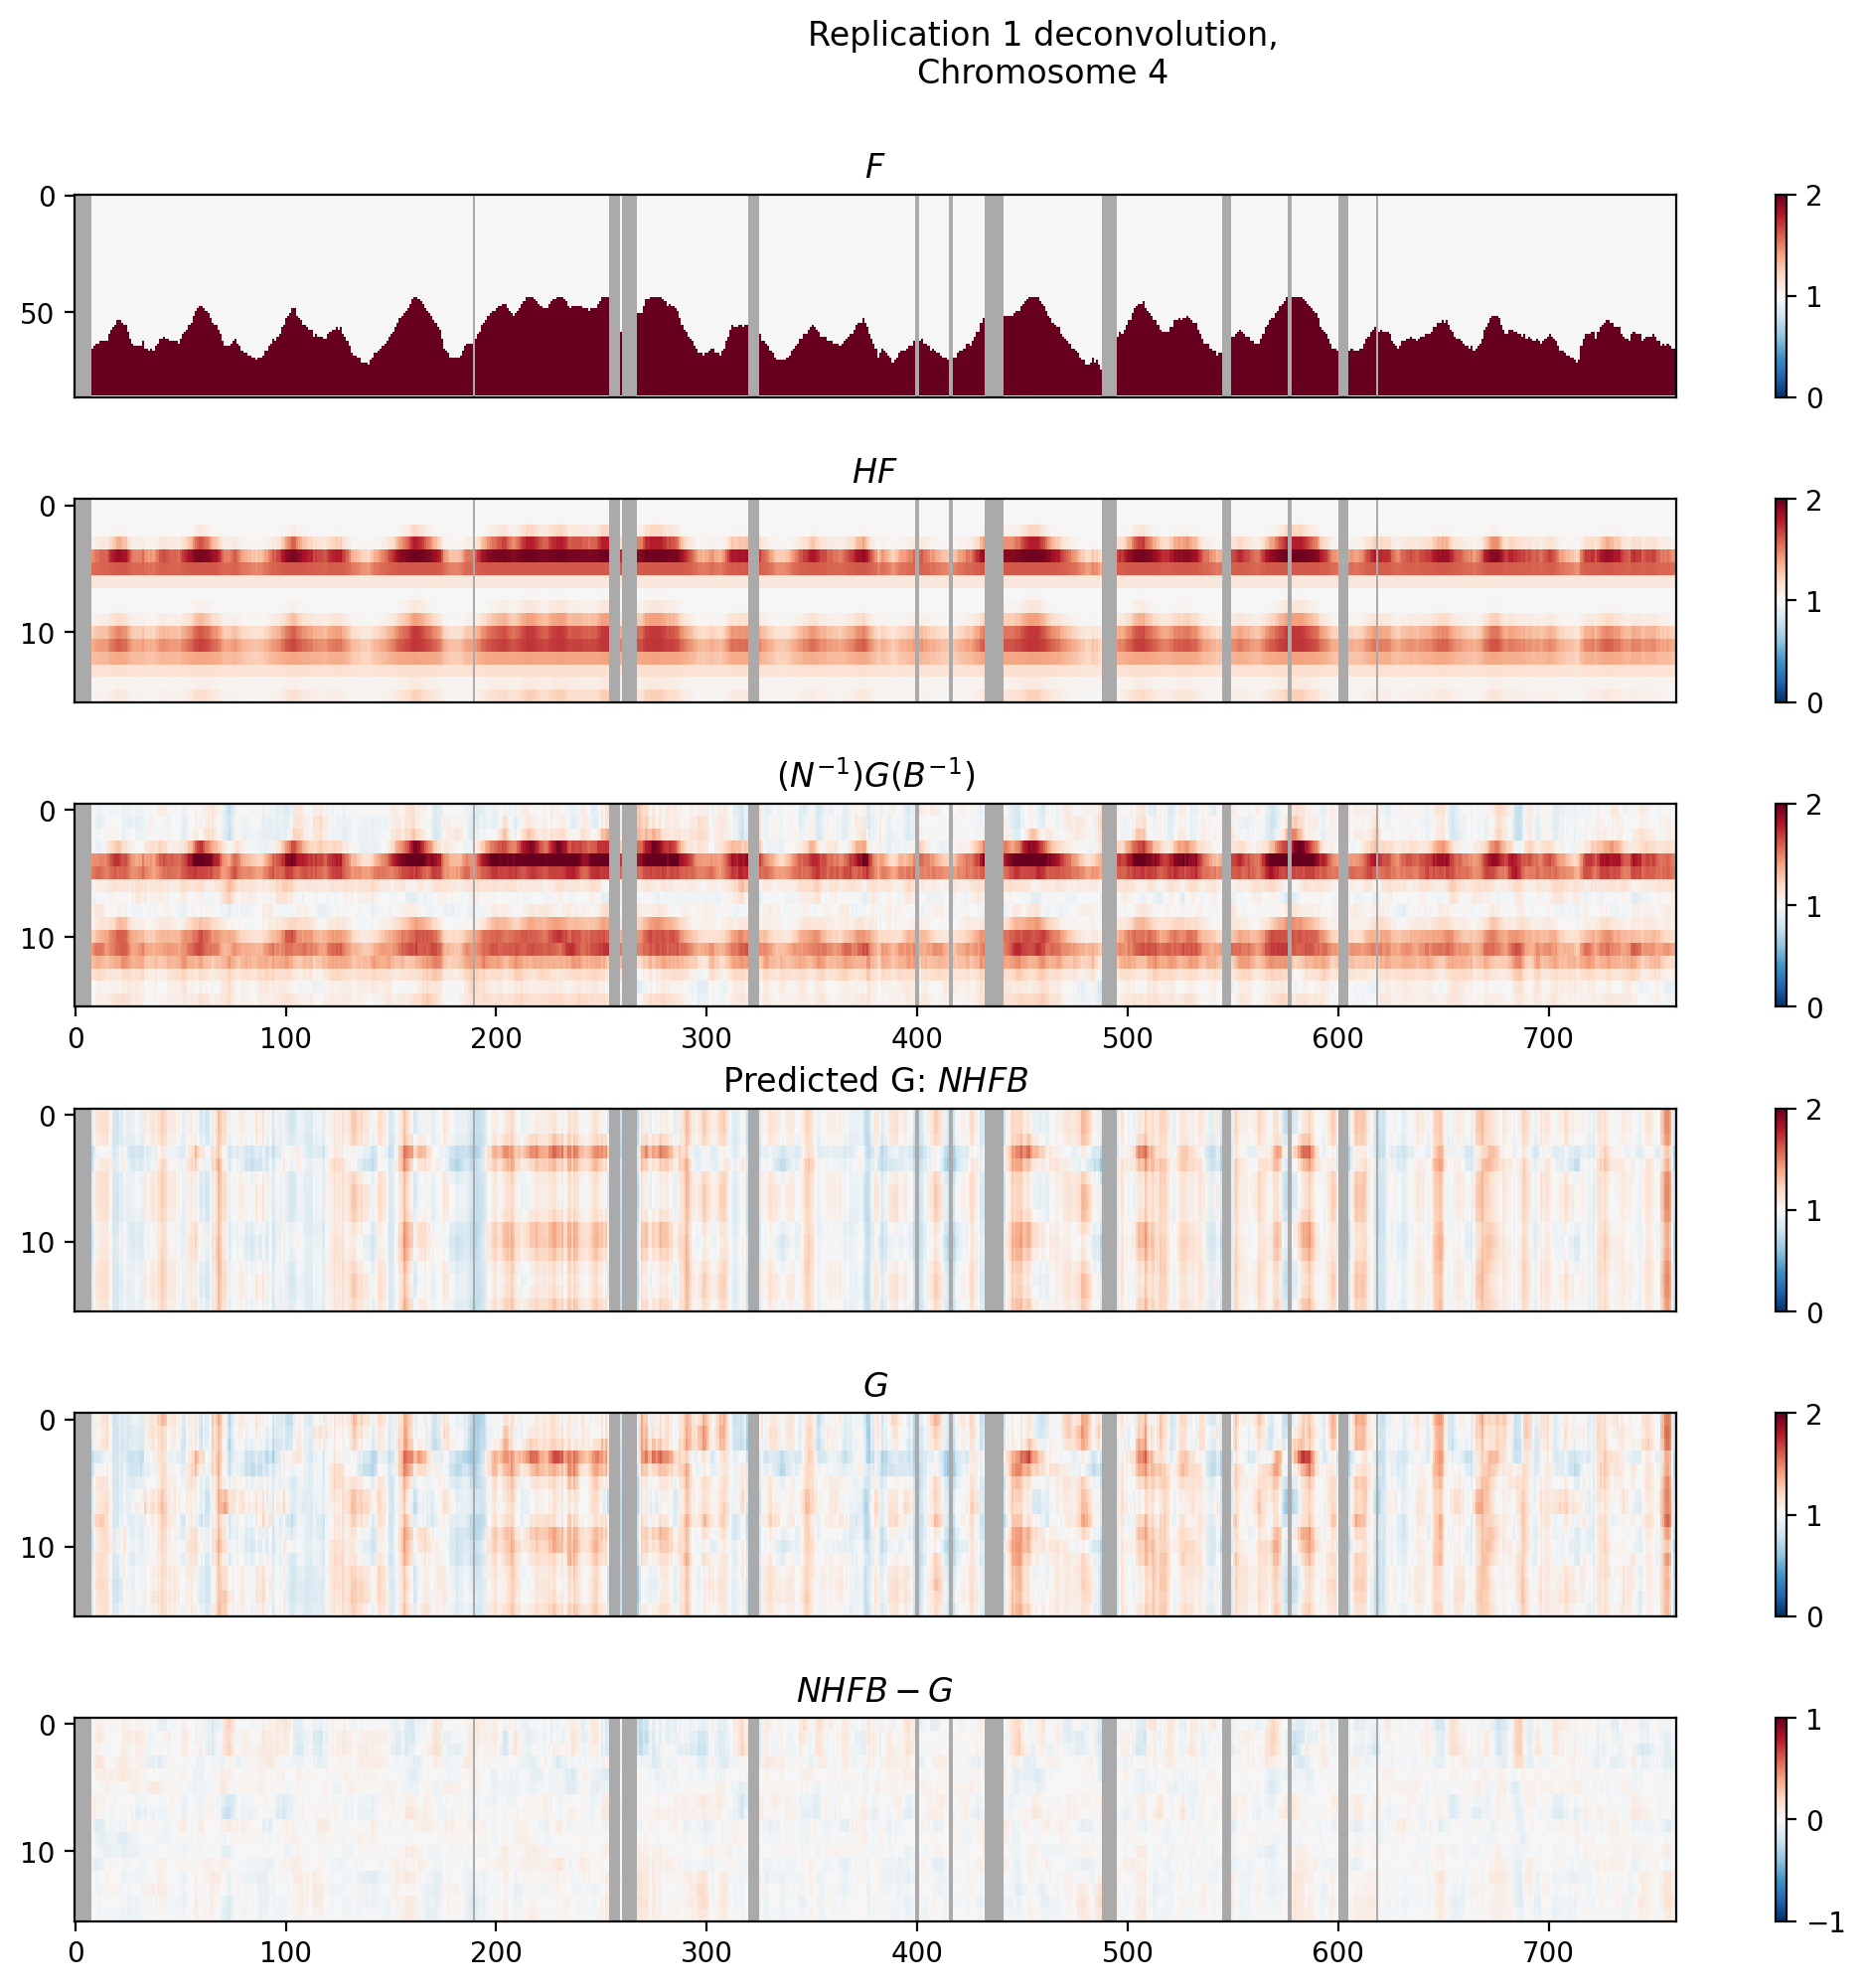

In [111]:
real_deconv1.plot_heatmaps()

In [112]:
# Let's determine if there is a way to identify and filter out the sites that are driving 
# gamma1 and 2 late, my suspicion is these are the alpha factor affected sites.
# If we exclude these sites from the loss calculation, does gamma1 and gamma2 learn
# more realistic values?

# Continue investigation: Identify sites that are driving for a late replication timing
# What is the reasoning for a replication timing of 80-100%?
from src.RealDataReplication import plot_heatmaps
        
def plot_epoch(epoch, real_deconv1):
    N, F, H, B = Ns[epoch], Fs[epoch], Hs[epoch], Bs[epoch]
    plot_heatmaps(N, F, H, B, 
                 real_deconv1.G, column_names=real_deconv1.masked_G_df.columns,
                 full_column_names=real_deconv1.G_df.columns)
    

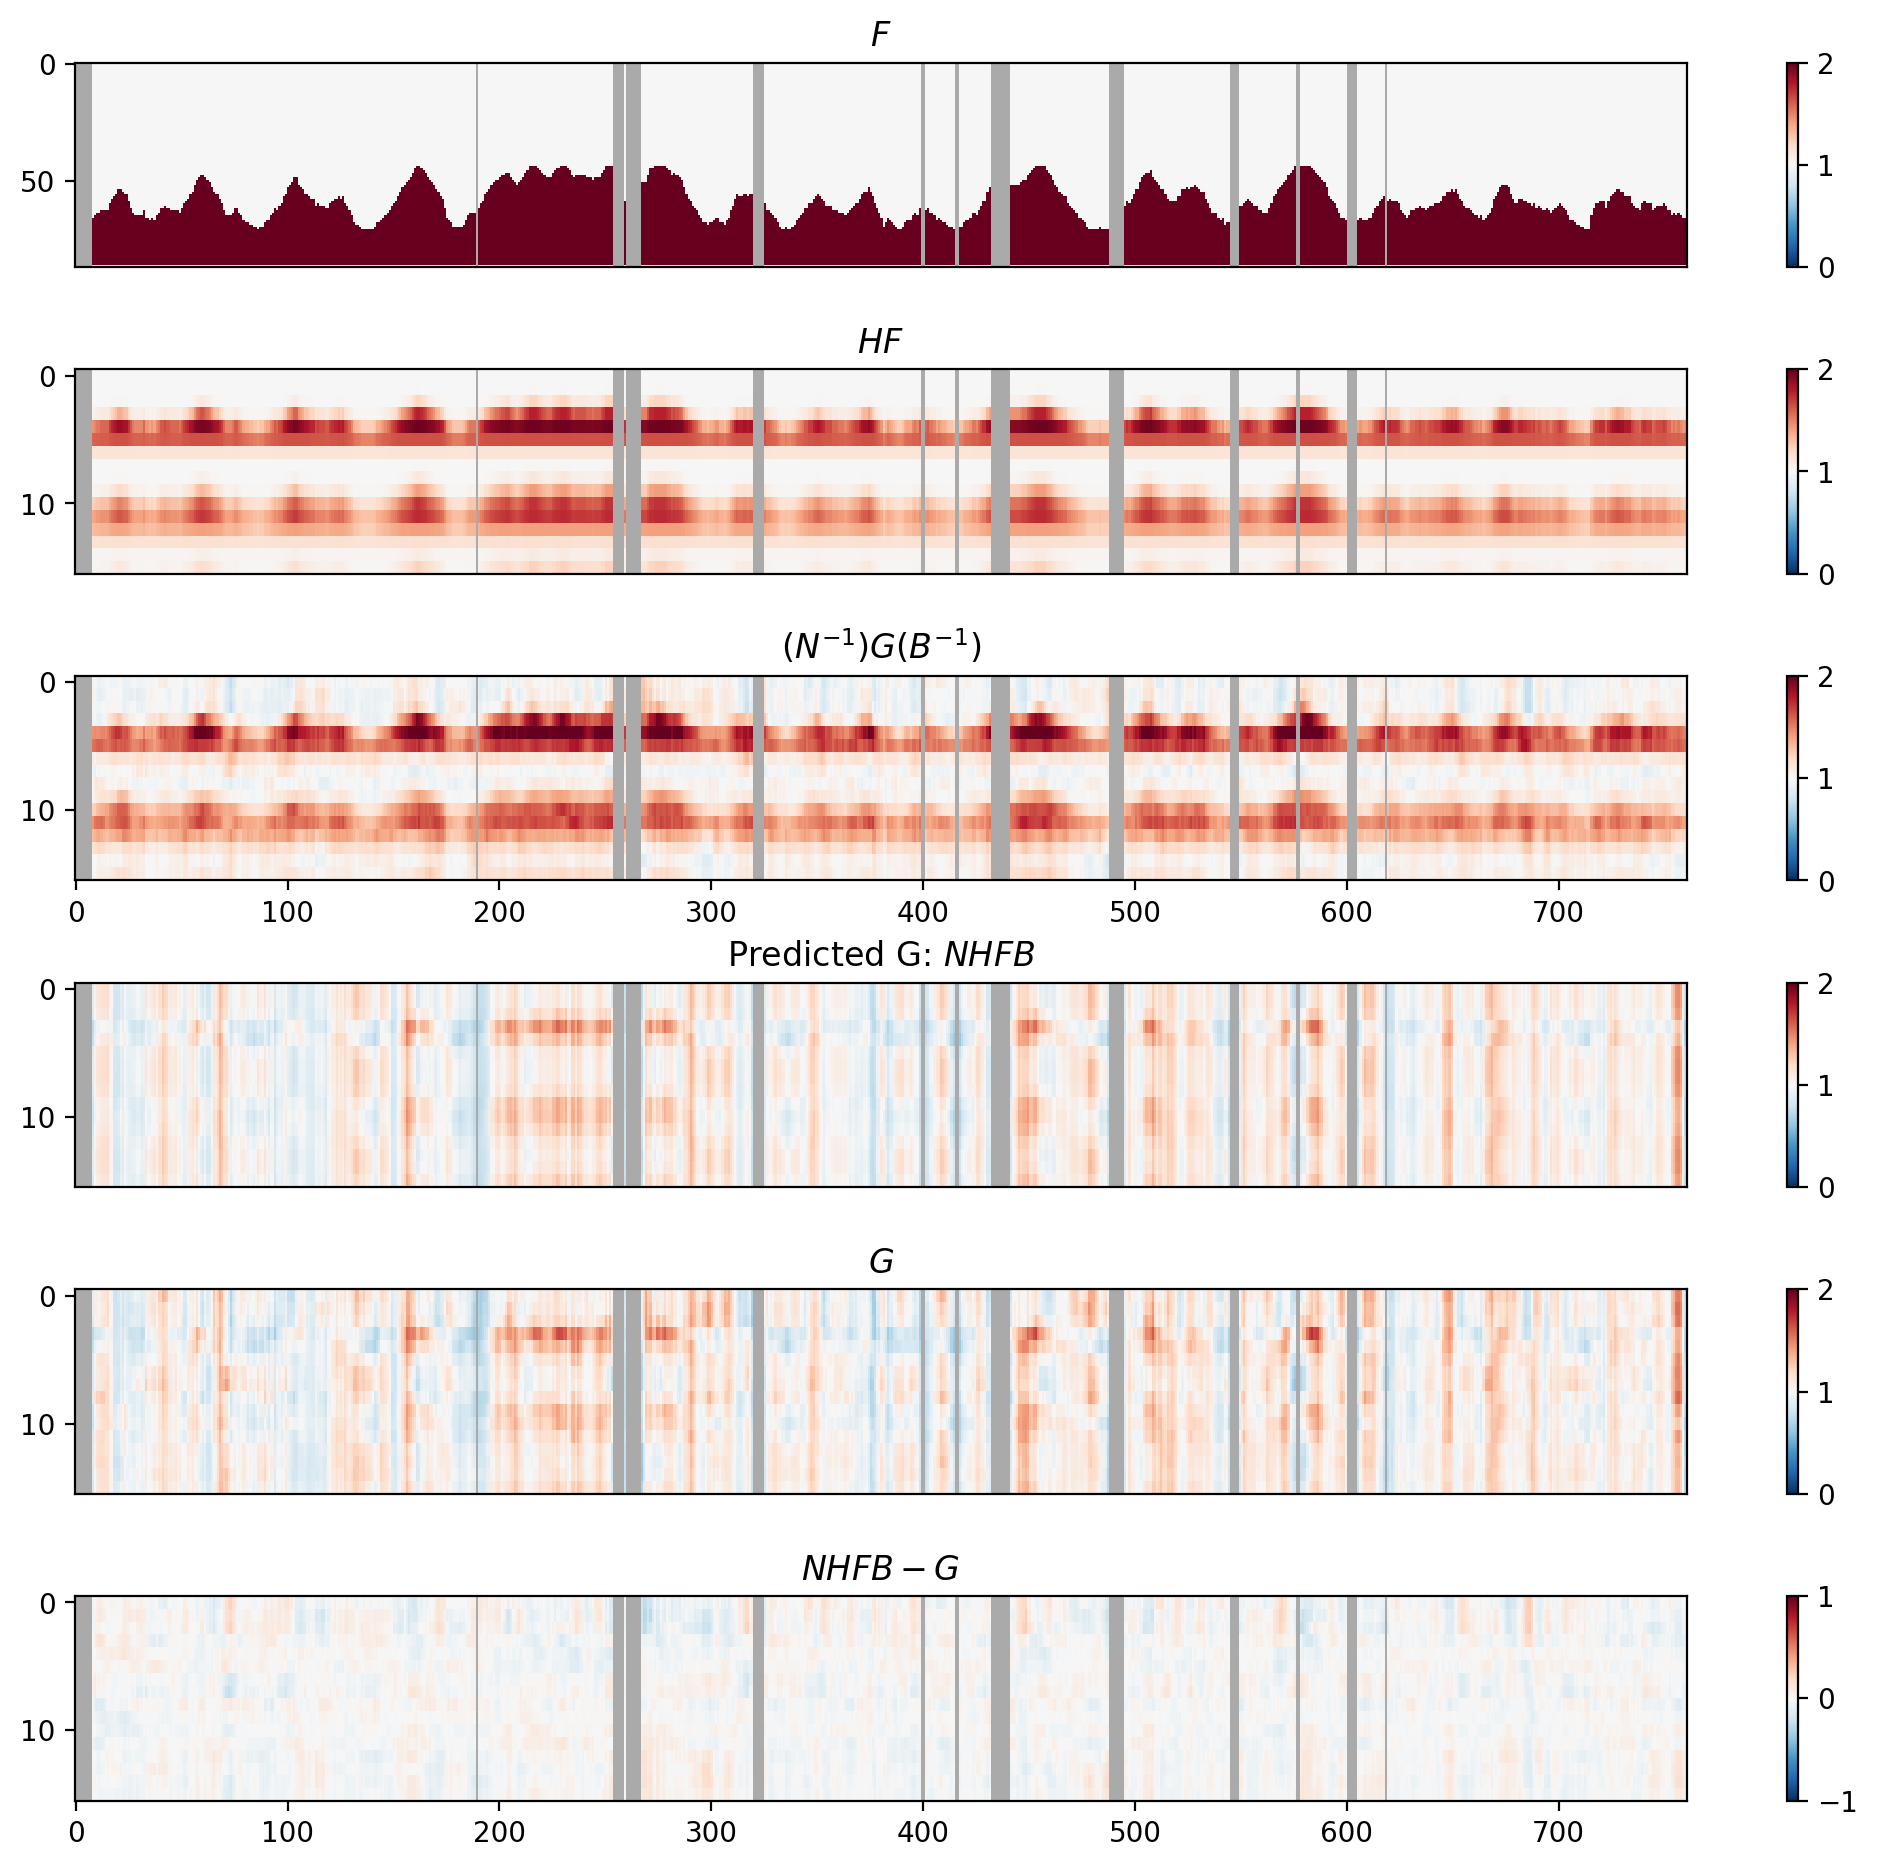

In [113]:
plot_epoch(0, real_deconv1)

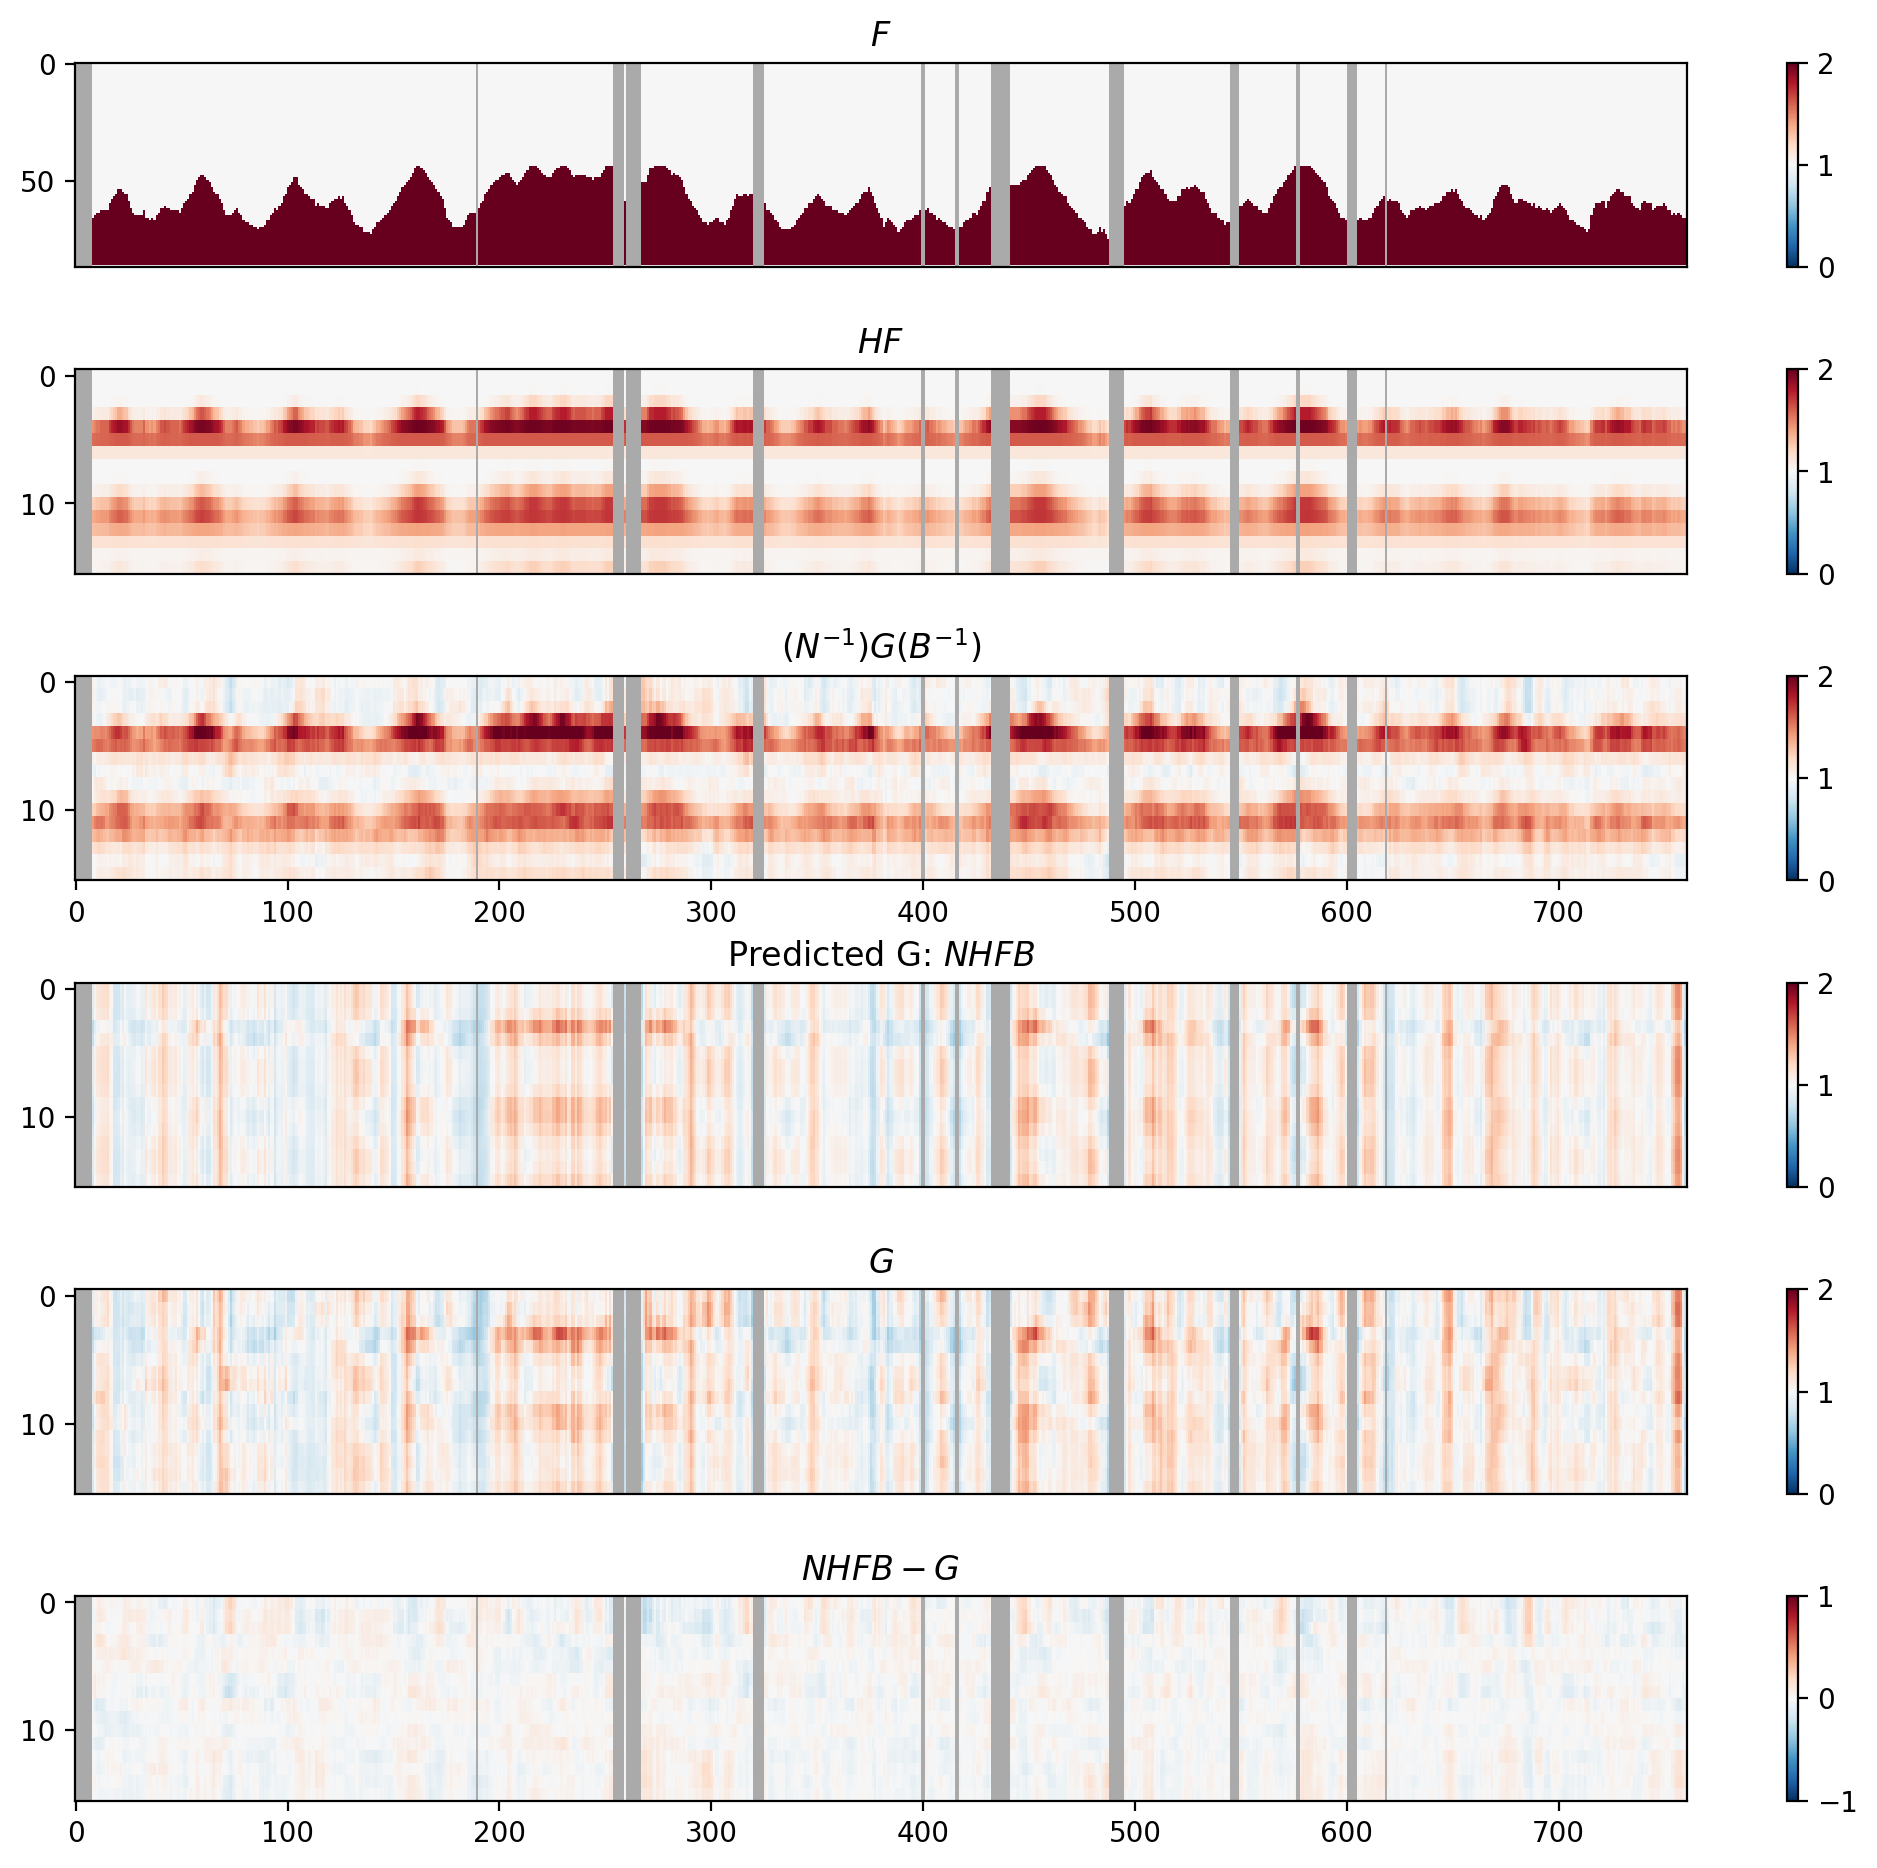

In [114]:
plot_epoch(9, real_deconv1)

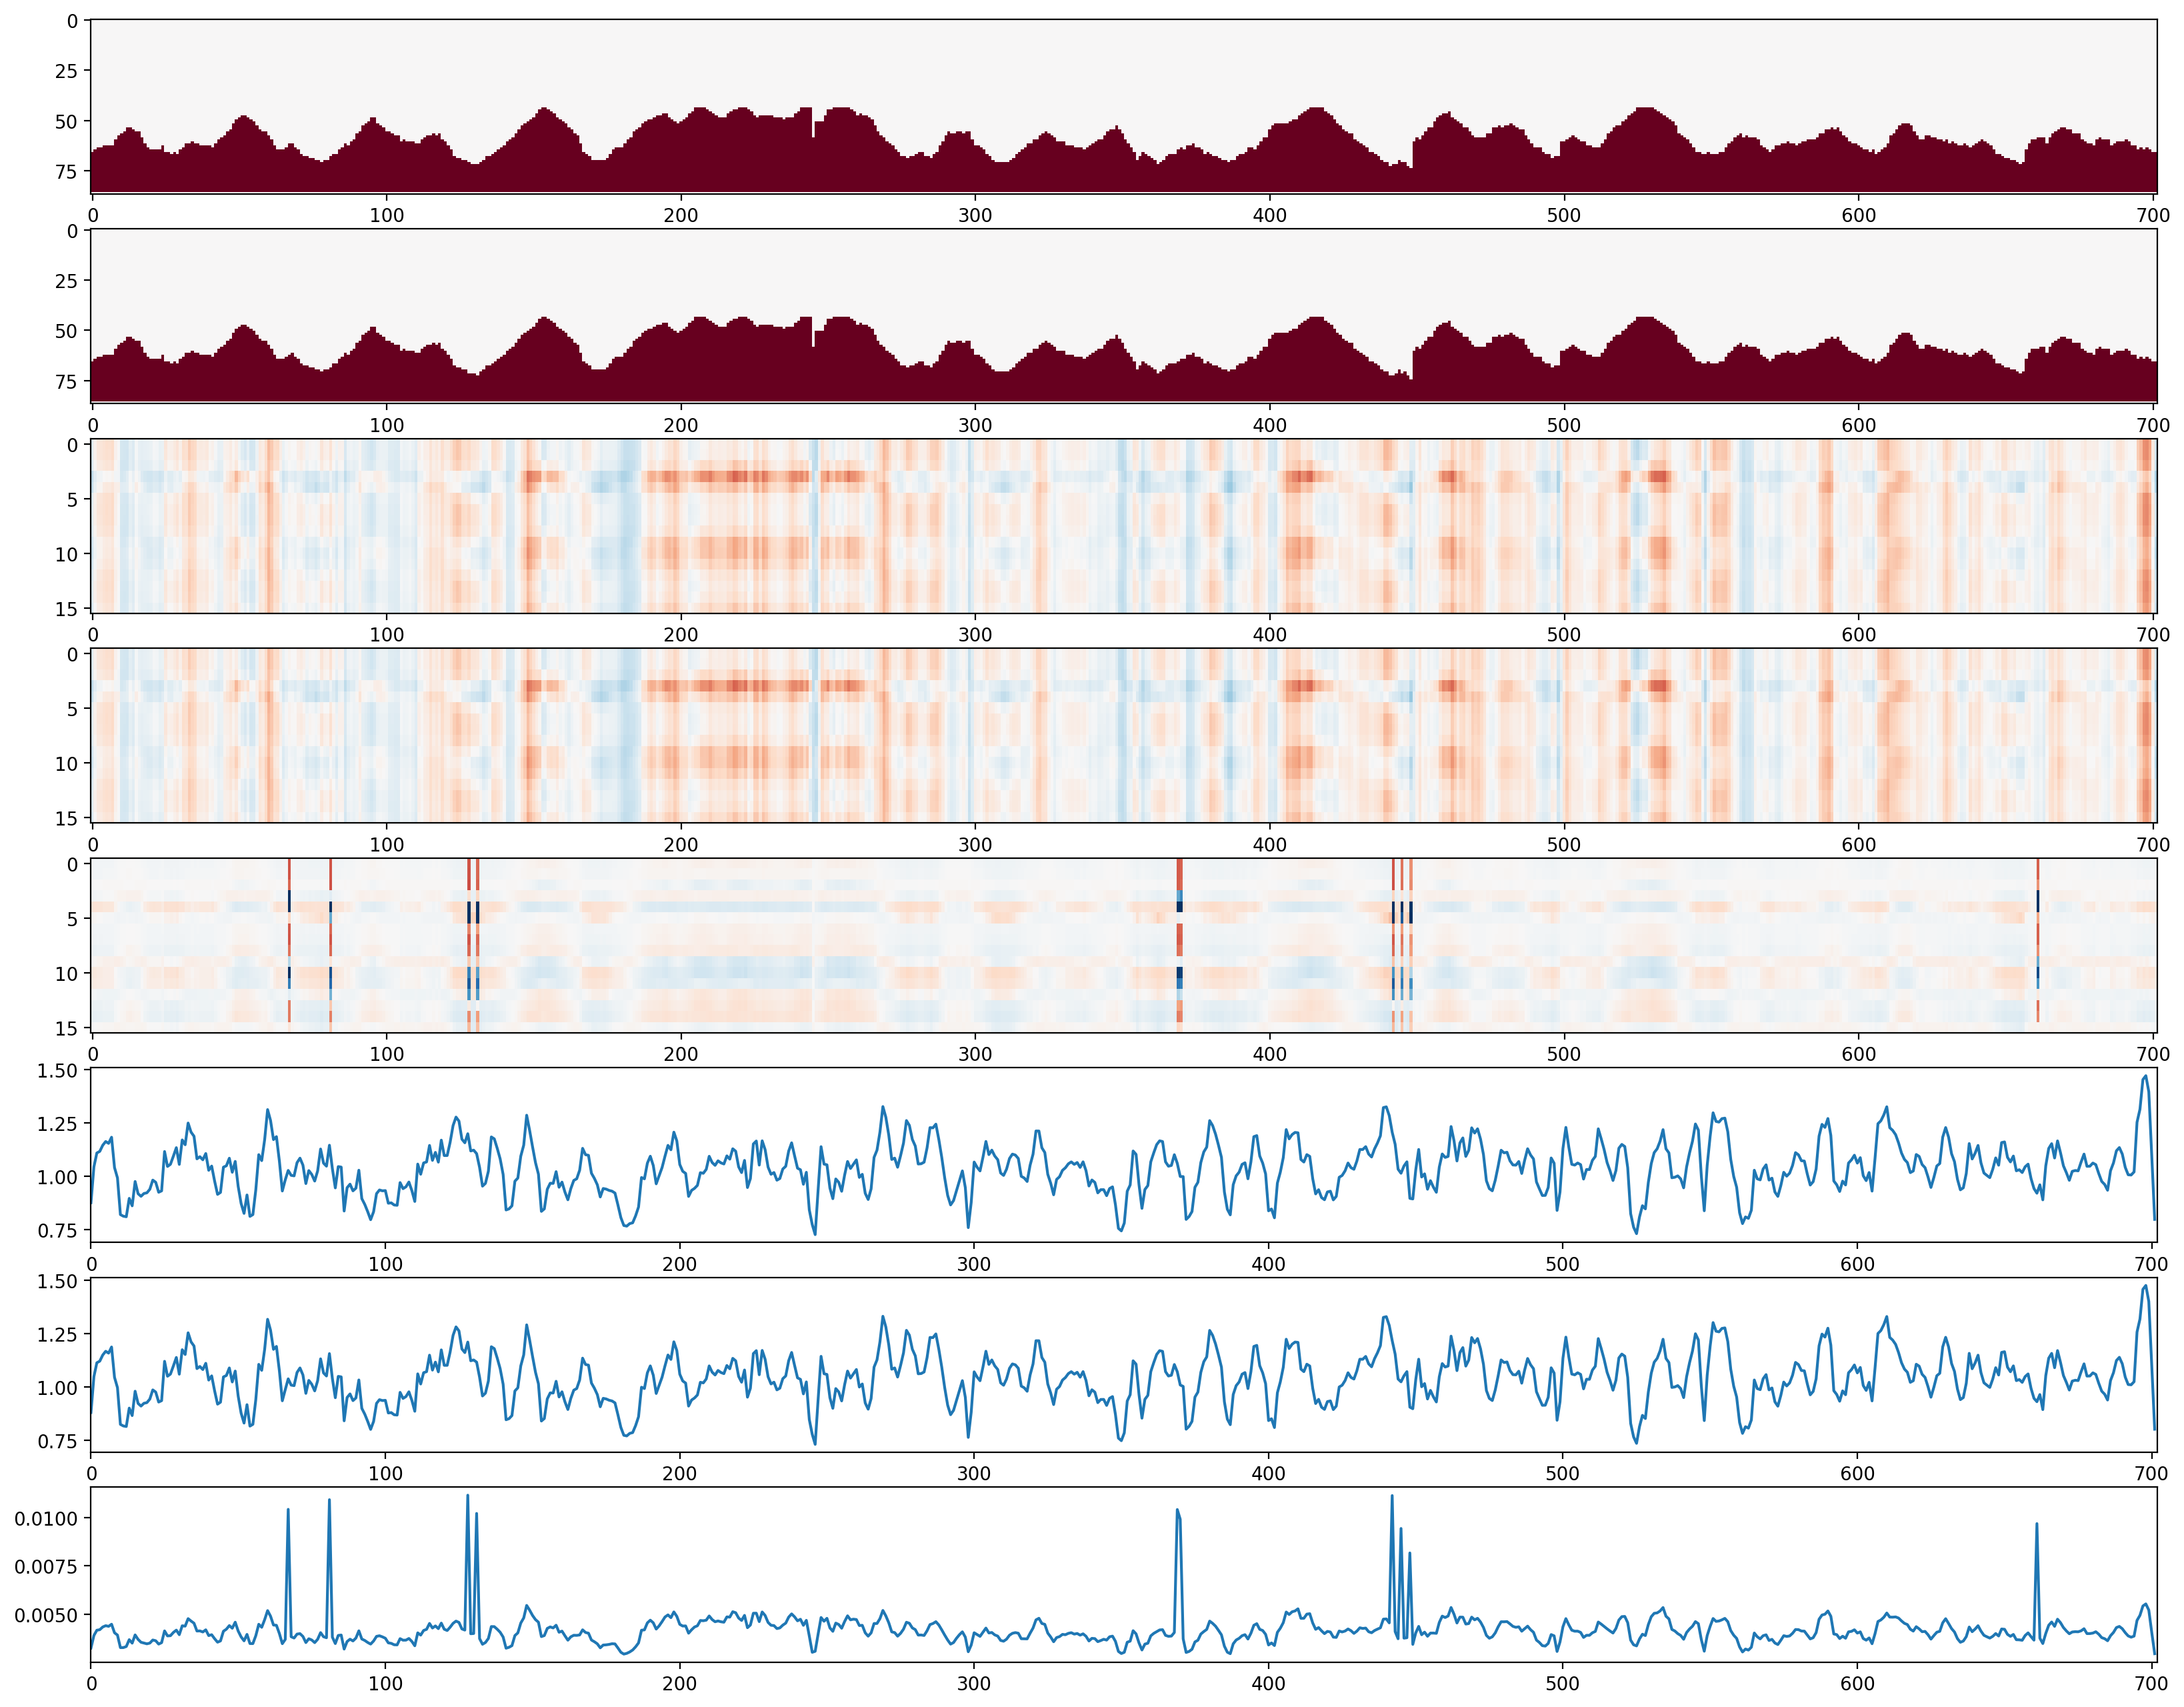

In [115]:

def compare_epochs(epoch1, epoch2, real_deconv1):
    N1, F1, H1, B1 = Ns[epoch1], Fs[epoch1], Hs[epoch1], Bs[epoch1]
    N2, F2, H2, B2 = Ns[epoch2], Fs[epoch2], Hs[epoch2], Bs[epoch2]
    G = real_deconv1.G
    
    predicted_1 = N1@H1@F1@B1
    predicted_2 = N2@H2@F2@B2
    
    diff = predicted_2 - predicted_1
    
    numrows = 8
    
    fig = plt.figure(figsize=(20, 16))
    plt.subplot(numrows, 1, 1)
    plt.imshow(F1, aspect='auto', vmin=0, vmax=2, cmap='RdBu_r')

    plt.subplot(numrows, 1, 2)
    plt.imshow(F2, aspect='auto', vmin=0, vmax=2, cmap='RdBu_r')

    plt.subplot(numrows, 1, 3)
    plt.imshow(predicted_1, aspect='auto', vmin=0, vmax=2, cmap='RdBu_r')
    
    plt.subplot(numrows, 1, 4)
    plt.imshow(predicted_2, aspect='auto', vmin=0, vmax=2, cmap='RdBu_r')

    plt.subplot(numrows, 1, 5)
    plt.imshow(diff, aspect='auto', vmin=-0.01, vmax=0.01, cmap='RdBu_r')

    plt.subplot(numrows, 1, 6)
    plt.plot(np.diag(B1))
    plt.xlim(0, F1.shape[1])

    plt.subplot(numrows, 1, 7)
    plt.plot(np.diag(B2))
    plt.xlim(0, F1.shape[1])

    plt.subplot(numrows, 1, 8)
    plt.plot(np.diag(B2)-np.diag(B1))
    plt.xlim(0, F1.shape[1])

    return (N1, H1, F1, B1, predicted_1), (N2, H2, F2, B2, predicted_2)

(N1, H1, F1, B1, predicted_1), \
(N2, H2, F2, B2, predicted_2) = compare_epochs(5, 9, real_deconv1)

Current analysis aims to identify the drivers for a later S-phase. Currently I am examining how B changes from an older epoch to a new one. My hunch is I am seeing what happens when certain replication timings adjust, and how that affects the fit. But there is not a clear indication that any of these individual sites drive for a shorter G2/M phase.

There does appear to be a handful of sites that are consistently greater in change in B than the previous epochs. They could be masked out, but there isn't a clear indication of why these sites are different than the rest.

Hunch, the number of iterations for N and B should be increased. The replication timings may need more iterations to settle in. The driving force behind how B changes appears to be when a replication time for a specific window is updated. These updates appear to happen iteratively on each epoch, but there isn't a clear indication of when or why some of the sites are adjusted.

I could cumulative see which sites have changed the most over time, this appears to to be the case for the comparison from 0 to 10...
